## Extract the average scores from result files

### imports

In [1]:
import os
import regex
import sys
import json

In [ ]:
# get the average scores from result files
def get_scores(fname):
    if not os.path.exists(fname):
        print(f"File {fname} does not exist")
        return

    pattern = r'^\|\s([A-Za-z]*)\s+\|\s+([0-9]\.?[0-9]*?)\s+\|\s+([0-9]\.?[0-9]*?)\s+\|'
    match_scores = regex.compile(pattern)
    scores = {}
    with open(fname, 'r') as f:
        lines = f.readlines()
    for line in lines:
        match_pattern = match_scores.match(line)
        if match_pattern:
            facet = match_pattern.group(1).strip()
            avg = match_pattern.group(2)
            # std = match_pattern.group(3)
            scores[facet] = float(avg)
    return scores

def get_model_data(model_name):
    if model_name is None:
        print("Please provide the model name")
    
    # folder where the results are stored
    resp_fmts = {"number": None, "label": None , "text": None }
    orders = {"shuffle": resp_fmts, "no-shuffle": resp_fmts }
    model_data = {"category": orders, "individual": orders}
    
    for type in model_data.keys():
        t_name = os.path.join( os.getcwd(), "results", model_name, type)
        for order in model_data[type].keys():
            if order == "shuffle":
                o_name = os.path.join(t_name, "shuffled")
            else:
                o_name = t_name
            for resp_fmt in model_data[type][order].keys():
                fname = os.path.join(o_name, f"results_{resp_fmt}.md")
                model_data[type][order][resp_fmt] = get_scores(fname)
    
    return model_data

In [78]:

result_data = {
 'llama-3-8b-instruct': None,
 'Llama-3.2-3B-Instruct': None,
 'llama-3.3-70b-instruct': None,
 'Qwen3-14B': None,
 'Qwen3-4B-Instruct-2507': None,
 'Qwen3-8B': None }

result_data = {model: get_model_data(model) for model in result_data.keys()}


### save the result data to a json file

In [ ]:
# json_str = json.dumps(result_data, indent=2, ensure_ascii=False)  # pretty-printed

with open("bfi_quantitative_results.json", "w", encoding="utf-8") as f:
    json.dump(result_data, f, indent=2, ensure_ascii=False)

### Read files and plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

with open("bfi_quantitative_results.json", "r") as f:
    raw = json.load(f)

records = []
for model, tests in raw.items():
    for test_type, shuffles in tests.items():
        for shuffle_cond, response_dict in shuffles.items():
            for response_type, values in response_dict.items():
                for f,v in values.items():
                    records.append({
                        "Model": model,
                        "TestType": test_type,
                        "Shuffle": shuffle_cond,
                        "ResponseType": response_type,
                        "Facet": f,
                        "Score": float(v)
                    })

df = pd.DataFrame(records)
df.head(10)


,Model,TestType,Shuffle,ResponseType,Facet,Score
0,llama-3-8b-instruct,category,shuffle,number,Agreeableness,4.11
1,llama-3-8b-instruct,category,shuffle,number,Conscientiousness,3.76
2,llama-3-8b-instruct,category,shuffle,number,Extraversion,3.39
3,llama-3-8b-instruct,category,shuffle,number,Neuroticism,2.48
4,llama-3-8b-instruct,category,shuffle,number,Openness,3.73
5,llama-3-8b-instruct,category,shuffle,label,Agreeableness,3.40
6,llama-3-8b-instruct,category,shuffle,label,Conscientiousness,3.06
7,llama-3-8b-instruct,category,shuffle,label,Extraversion,3.57
8,llama-3-8b-instruct,category,shuffle,label,Neuroticism,3.11
9,llama-3-8b-instruct,category,shuffle,label,Openness,4.17


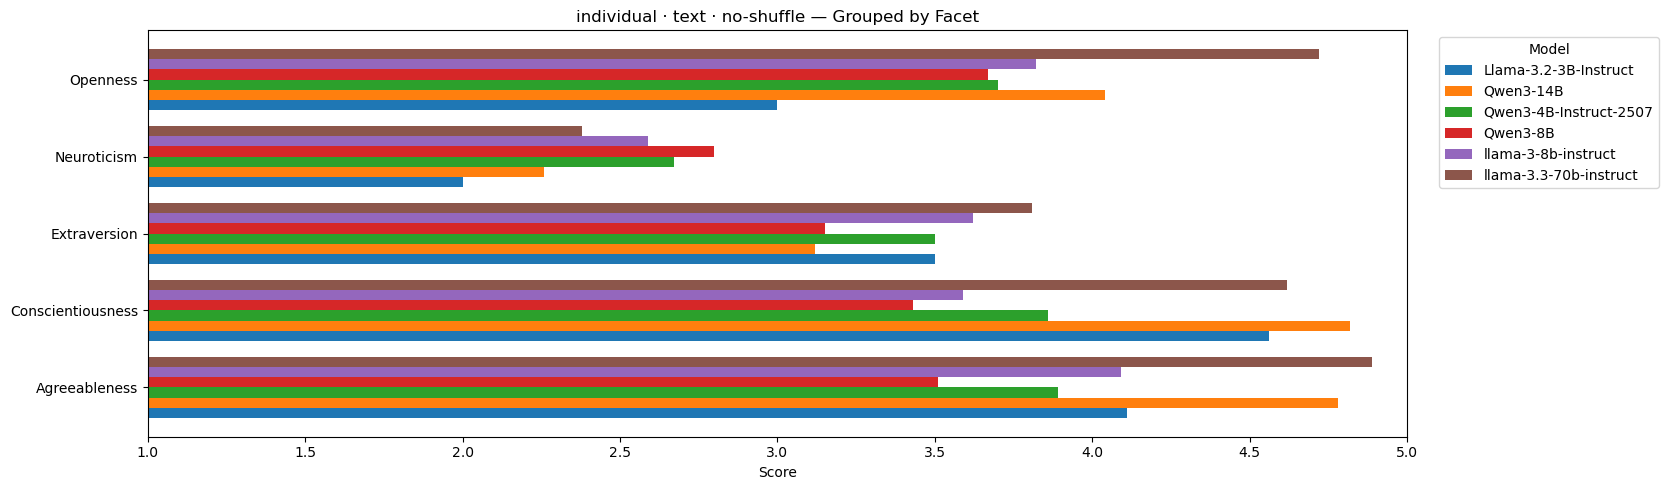

In [102]:
def plot_grouped_bars(df, test_type, shuffle, response_type,
                      facet_col="Facet", model_col="Model", score_col="Score",
                      x_min=1.0, x_max=5.0, title=None):
    """
    Grouped horizontal bars:
      - Y groups = facets (e.g., 5 categories)
      - Within each group = one bar per Model (offset vertically)
    Filters by TestType, Shuffle, ResponseType.
    """
    d = df[(df["TestType"] == test_type) &
           (df["Shuffle"] == shuffle) &
           (df["ResponseType"] == response_type)].copy()

    if d.empty:
        raise ValueError("No rows after filtering; check your filters.")

    # Pivot to rows=Facet, cols=Model, values=Score (mean in case of duplicates)
    wide = (d.pivot_table(index=facet_col, columns=model_col, values=score_col, aggfunc="mean")
              .sort_index())

    facets = wide.index.to_list()
    models = wide.columns.to_list()
    vals = wide.values    # shape: (n_facets, n_models)

    n_facets, n_models = vals.shape
    y_groups = np.arange(n_facets)

    # Cluster layout: each group gets height ~0.8, split across n_models
    cluster_height = 0.8
    bar_height = cluster_height / max(n_models, 1)

    plt.figure(figsize=(max(8, 1.8 * n_models + 6), max(5, 0.6 * n_facets + 2)))

    # Plot each model offset within the facet group
    for i, m in enumerate(models):
        offsets = y_groups - (cluster_height / 2) + (i + 0.5) * bar_height
        plt.barh(offsets, wide[m].to_numpy(), height=bar_height, label=m)

    plt.yticks(y_groups, facets)
    plt.xlim(x_min, x_max)      # keep the 1.0–5.0 scale
    plt.xlabel("Score")
    if title is None:
        title = f"{test_type} · {response_type} · {shuffle} — Grouped by {facet_col}"
    plt.title(title)
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_grouped_bars(df, "individual", "no-shuffle", "text")

### Plot the radar chart

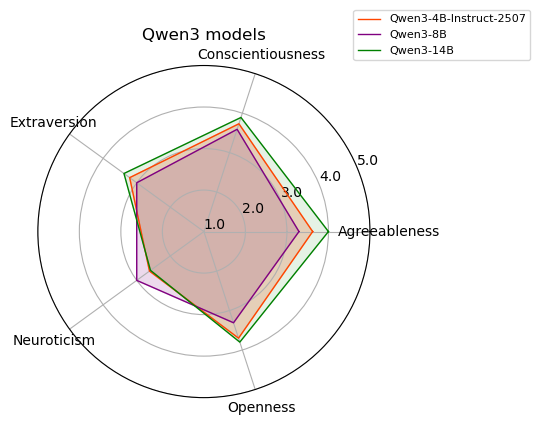

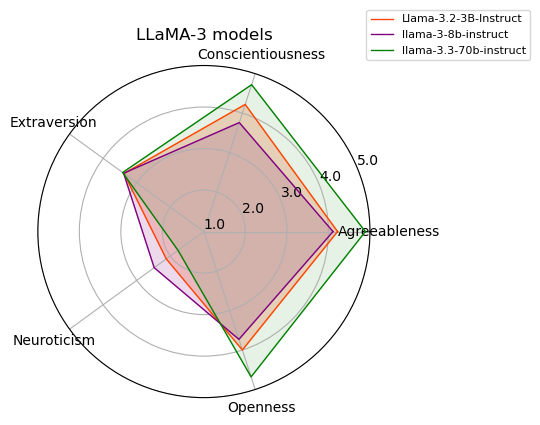

In [231]:
import numpy as np
import matplotlib.pyplot as plt
import re

def sort_by_facets(facets):
    # Keep a sensible order like Type1..Type5 if present; otherwise alphabetical
    def key_fn(s):
        m = re.search(r'(\d+)$', str(s))
        return (str(s), int(m.group(1))) if m else (str(s), 0)
    return sorted(facets, key=key_fn)

def get_polar_overlay(df, models, test_type="individual", response_type="text", shuffle="no-shuffle",
                  facet_order=None, title=None):
    df_grouped = df[(df["TestType"] == test_type) &
           (df["ResponseType"] == response_type) &
           (df["Shuffle"] == shuffle)].copy()
    if df_grouped.empty:
        raise ValueError("No rows after filtering; check TestType/ResponseType/Shuffle.")

    if facet_order is None:
        facet_order = sort_by_facets(df_grouped["Facet"].unique())

    # angles around the circle
    N = len(facet_order)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False)

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    cmap = ["orangered", "purple", "green"]  # change colors
    alphas = [0.2, 0.15, 0.1]  # transparency levels for fill
    for idx,m in enumerate(models):
        dm = df_grouped[df_grouped["Model"] == m].set_index("Facet")
        # get values in the chosen facet order
        vals = [dm.loc[f, "Score"] if f in dm.index else np.nan for f in facet_order]
        vals = np.array(vals, dtype=float)

        # close the polygon
        vals_closed = np.concatenate([vals, vals[:1]])
        ang_closed  = np.concatenate([angles, angles[:1]])

        ax.plot(ang_closed, vals_closed, linewidth=1, linestyle='solid', color=cmap[idx], label=m)  
        ax.fill(ang_closed, vals_closed, color=cmap[idx], alpha=alphas[idx])
    

    # radial axis: fixed 1–5 scale
    ax.set_ylim(1.0, 5.0)
    ax.set_yticks([1.0, 2.0, 3.0, 4.0, 5.0])
    ax.set_yticklabels(["1.0", "2.0", "3.0", "4.0", "5.0"])

    # facet labels
    ax.set_xticks(angles)
    ax.set_xticklabels(facet_order)

    if title is None:
        title = models[0].split("-")[0]
    ax.set_title(title, fontsize=12)

    ax.legend(loc="lower right",fontsize=8 , bbox_to_anchor=(1.5, 1))
    plt.tight_layout()
    figname = f"{title}_test-{test_type}_resp-{response_type}_{shuffle}_polar.png"
    plt.savefig(figname, dpi=300)
    plt.show()
    
    
get_polar_overlay(df, models=["Qwen3-4B-Instruct-2507", "Qwen3-8B", "Qwen3-14B"],
    test_type="individual",
    response_type="number",
    shuffle="shuffle",
    title="Qwen3 models"
)
get_polar_overlay(df, models=["Llama-3.2-3B-Instruct", "llama-3-8b-instruct", "llama-3.3-70b-instruct"],
    test_type="individual",
    response_type="number",
    shuffle="no-shuffle",
    title="LLaMA-3 models"
)

## Pairwise Mann–Whitney U

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [ ]:
# -----------------------------
# Utility functions
# -----------------------------

category_names = {
    'E': "Extraversion",
    'A': "Agreeableness",
    'C': "Conscientiousness",
    'N': "Neuroticism",
    'O': "Openness"
}

def get_level_trait_scores(df: pd.DataFrame) -> pd.DataFrame:
    """
    From a single 44-row BFI CSV with columns:
    - 'category' in {E,A,C,N,O}
    - response_1 ... response_k (k runs)
    Returns long-form dataframe with columns: ['trait','run','score']
    """
    responses = df.filter(like="response_")
    trait_by_run = df.groupby("category")[responses.columns].mean()
    long_df = trait_by_run.stack().reset_index()
    long_df.columns = ["trait", "run", "score"]
    # keep canonical order
    long_df["trait"] = pd.Categorical(long_df["trait"], categories=["E","A","C","N","O"], ordered=True)
    return long_df


#  pairwise MWU for two different files
def pairwise_mwu_two_files(file_1: str, label_1: str,
                            file_2: str, label_2: str,
                            save_prefix: str = "pairwise_results") -> pd.DataFrame:
    """
    Load two BFI CSVs  compute level trait scores,
    run two-sided Mann–Whitney U test for each trait (E, A, C, N, O),
    save a CSV summary.    
    Returns the results DataFrame.
    """
    
    # collect results per trait
    results = []
    traits = ["E","A","C","N","O"]

    # Load the CSVs                
    df1 = pd.read_csv(file_1)
    df2 = pd.read_csv(file_2)                     
        
    # Compute run-level scores
    s1 = get_level_trait_scores(df1).rename(columns={"score": "score1"})
    s2 = get_level_trait_scores(df2).rename(columns={"score": "score2"})
    
    for t in traits:
        x = s1[s1["trait"] == t]["score1"].values
        y = s2[s2["trait"] == t]["score2"].values
        
        # MWU two-sided
        U, p = mannwhitneyu(x, y, alternative="two-sided")
        
        results.append({
            "trait": category_names.get(t, t),
            "M1": label_1,
            "M2": label_2,
            "mean_M1": np.round(np.mean(x),2),
            "mean_M2": np.round(np.mean(y),2),
            "U": float(U),
            "p_value": float(p),
        })
            
    # Save results
    res_df = pd.DataFrame(results)
    out_csv = f"{save_prefix}_{label_1}_VS_{label_2}-{Path(file_1).stem.split('_')[-1]}.csv"
    res_df.to_csv(out_csv, index=False)
    return res_df, out_csv


#  pairwise MWU between two models' CSVs

def pairwise_mwu_two_models(file_model1: str, label_model1: str,
                            file_model2: str, label_model2: str,
                            save_prefix: str = "pairwise_results") -> pd.DataFrame:
    """
    Load two Modles CSVs, compute level trait scores,
    run two-sided Mann–Whitney U test for each trait (E, A, C, N, O),
    save a CSV summary.    
    Returns the results DataFrame.
    """
    
    # collect results per trait
    results = []
    traits = ["E","A","C","N","O"]
    response_types = ["label", "number", "text"]
    
    for response_type in response_types:
        # Load the CSVs                
        df1 = pd.read_csv(os.path.join(file_model1, f"bfi_responses_{response_type}.csv"))
        df2 = pd.read_csv(os.path.join(file_model2, f"bfi_responses_{response_type}.csv") )                     
        
        # Compute run-level scores
        s1 = get_level_trait_scores(df1).rename(columns={"score": "score1"})
        s2 = get_level_trait_scores(df2).rename(columns={"score": "score2"})
        
        for t in traits:
            x = s1[s1["trait"] == t]["score1"].values
            y = s2[s2["trait"] == t]["score2"].values
            
            # MWU two-sided
            U, p = mannwhitneyu(x, y, alternative="two-sided")
            
            results.append({
                "trait": category_names.get(t, t),
                "model1": label_model1,
                "model2": label_model2,
                "label" : response_type,
                "mean_M1": np.round(np.mean(x),2),
                "mean_M2": np.round(np.mean(y),2),
                "U": float(U),
                "p_value": float(p),
            })

    # Save results
    res_df = pd.DataFrame(results)
    out_csv = f"{save_prefix}_{label_model1}_VS_{label_model2}-{Path(file_model2).stem}.csv"
    res_df.to_csv(out_csv, index=False)
    return res_df, out_csv



def pairwise_mwu_across_response_types(file_1: str, label_1: str,
                            save_prefix: str = "pairwise_results") -> pd.DataFrame:
    """
    Load two Modles CSVs, compute level trait scores,
    run two-sided Mann–Whitney U test for each trait (E, A, C, N, O),
    save a CSV summary.    
    Returns the results DataFrame.
    """
    
    # collect results per trait
    results = []
    traits = ["E","A","C","N","O"]
    response_types = ["label", "number", "text"]
    
    response_pairs = [("label","number"), ("label","text"), ("number","text")]
    
    for response_type1,response_type2 in response_pairs:
        # Load the CSVs                
        df1 = pd.read_csv(os.path.join(file_1, f"bfi_responses_{response_type1}.csv"))
        df2 = pd.read_csv(os.path.join(file_1, f"bfi_responses_{response_type2}.csv") )                     
        
        # Compute run-level scores
        s1 = get_level_trait_scores(df1).rename(columns={"score": "score1"})
        s2 = get_level_trait_scores(df2).rename(columns={"score": "score2"})
        
        for t in traits:
            x = s1[s1["trait"] == t]["score1"].values
            y = s2[s2["trait"] == t]["score2"].values
            
            # MWU two-sided
            U, p = mannwhitneyu(x, y, alternative="two-sided")
            
            results.append({
                "trait": category_names.get(t, t),
                "M1": response_type1,
                "M2": response_type2,
                "label" : response_type1,
                "mean_M1": np.round(np.mean(x),2),
                "mean_M2": np.round(np.mean(y),2),
                "U": float(U),
                "p_value": float(p),
            })

    # Save results
    res_df = pd.DataFrame(results)
    out_csv = os.path.join(os.getcwd(),"statistical_results", f"{save_prefix}_{label_1}_across_response_types-{Path(file_1).stem}.csv")
    res_df.to_csv(out_csv, index=False)
    return res_df, out_csv

### Two different models 

In [54]:
# Qwen3-4B-Instruct-2507 vs Llama-3.2-3B-Instruct - category
file1 = os.path.join(os.getcwd(), "results/Llama-3.2-3B-Instruct/category/")
file2 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/category/")

model_results, demo_path = pairwise_mwu_two_models(
    file1, "Qwen3-4B",
    file2, "Llama3.2-3B",
    save_prefix="pairwise_results"
)

print(model_results)

                trait    model1       model2   label  mean_M1  mean_M2      U  \
0        Extraversion  Qwen3-4B  Llama3.2-3B   label     2.38     4.38    0.0   
1       Agreeableness  Qwen3-4B  Llama3.2-3B   label     4.44     4.44   50.0   
2   Conscientiousness  Qwen3-4B  Llama3.2-3B   label     5.00     4.44  100.0   
3         Neuroticism  Qwen3-4B  Llama3.2-3B   label     2.50     1.96  100.0   
4            Openness  Qwen3-4B  Llama3.2-3B   label     4.30     4.71    0.0   
5        Extraversion  Qwen3-4B  Llama3.2-3B  number     2.62     4.12    0.0   
6       Agreeableness  Qwen3-4B  Llama3.2-3B  number     4.56     4.44  100.0   
7   Conscientiousness  Qwen3-4B  Llama3.2-3B  number     4.22     4.33    0.0   
8         Neuroticism  Qwen3-4B  Llama3.2-3B  number     2.38     2.17   90.0   
9            Openness  Qwen3-4B  Llama3.2-3B  number     4.00     4.50    0.0   
10       Extraversion  Qwen3-4B  Llama3.2-3B    text     1.62     3.88    0.0   
11      Agreeableness  Qwen3

### shuffle Vs no-shuffle

In [71]:
file1 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/category/bfi_responses_number.csv")
file2 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/category/shuffled/bfi_responses_number.csv")

shuffle_results, demo_path = pairwise_mwu_two_files(
    file1, "shuffle",
    file2, "no-shuffle",
    save_prefix="Qwen3-4B-pairwise_results"
)

print(shuffle_results)

               trait       M1          M2  mean_M1  mean_M2     U   p_value
0       Extraversion  shuffle  no-shuffle     4.12     4.12  50.0  1.000000
1      Agreeableness  shuffle  no-shuffle     4.44     4.44  50.0  1.000000
2  Conscientiousness  shuffle  no-shuffle     4.33     4.33  50.0  1.000000
3        Neuroticism  shuffle  no-shuffle     2.17     2.22  40.0  0.366191
4           Openness  shuffle  no-shuffle     4.50     4.50  50.0  1.000000


In [81]:
# Qwen3-4B-Instruct-2507 vs Qwen3-4B-Instruct-2507 - category
file1 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/category/shuffled/")
file2 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/category/")

model_results, demo_path = pairwise_mwu_two_models(
    file1, "shuffle",
    file2, "no-shuffle",
    save_prefix="pairwise_results"
)

print(model_results)

                trait   model1      model2   label  mean_M1  mean_M2     U  \
0        Extraversion  shuffle  no-shuffle   label     4.38     4.38  50.0   
1       Agreeableness  shuffle  no-shuffle   label     4.44     4.44  50.0   
2   Conscientiousness  shuffle  no-shuffle   label     4.44     4.44  50.0   
3         Neuroticism  shuffle  no-shuffle   label     2.01     1.96  63.5   
4            Openness  shuffle  no-shuffle   label     4.66     4.71  35.5   
5        Extraversion  shuffle  no-shuffle  number     4.12     4.12  50.0   
6       Agreeableness  shuffle  no-shuffle  number     4.44     4.44  50.0   
7   Conscientiousness  shuffle  no-shuffle  number     4.33     4.33  50.0   
8         Neuroticism  shuffle  no-shuffle  number     2.22     2.17  60.0   
9            Openness  shuffle  no-shuffle  number     4.50     4.50  50.0   
10       Extraversion  shuffle  no-shuffle    text     3.88     3.88  50.0   
11      Agreeableness  shuffle  no-shuffle    text     4.11     

### Individual Vs category

In [72]:
file1 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/individual/bfi_responses_number.csv")
file2 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/category/bfi_responses_number.csv")

cat_results, demo_path = pairwise_mwu_two_files(
    file1, "individual",
    file2, "category",
    save_prefix="pairwise_results"
)

print(cat_results)

               trait          M1        M2  mean_M1  mean_M2      U   p_value
0       Extraversion  individual  category     3.21     4.12    0.0  0.000040
1      Agreeableness  individual  category     3.62     4.44    0.0  0.000046
2  Conscientiousness  individual  category     3.73     4.33    0.0  0.000046
3        Neuroticism  individual  category     2.62     2.17  100.0  0.000033
4           Openness  individual  category     3.70     4.50    0.0  0.000016


In [82]:
file1 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/individual")
file2 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/category")

cat_results, demo_path = pairwise_mwu_two_models(
    file1, "individual",
    file2, "category",
    save_prefix="pairwise_results"
)

print(cat_results)

                trait      model1    model2   label  mean_M1  mean_M2      U  \
0        Extraversion  individual  category   label     3.00     4.38    0.0   
1       Agreeableness  individual  category   label     3.24     4.44    0.0   
2   Conscientiousness  individual  category   label     3.37     4.44    0.0   
3         Neuroticism  individual  category   label     3.00     1.96  100.0   
4            Openness  individual  category   label     3.46     4.71    0.0   
5        Extraversion  individual  category  number     3.21     4.12    0.0   
6       Agreeableness  individual  category  number     3.62     4.44    0.0   
7   Conscientiousness  individual  category  number     3.73     4.33    0.0   
8         Neuroticism  individual  category  number     2.62     2.17  100.0   
9            Openness  individual  category  number     3.70     4.50    0.0   
10       Extraversion  individual  category    text     3.50     3.88    0.0   
11      Agreeableness  individual  categ

### number Vs text Vs label

In [83]:
file1 = os.path.join(os.getcwd(), "results/Qwen3-4B-Instruct-2507/category")

demo_results, demo_path = pairwise_mwu_across_response_types(
    file1, "Qwen3-4B-Instruct-2507",
    save_prefix="pairwise_results"
)

print(demo_results)

                trait      M1      M2   label  mean_M1  mean_M2      U  \
0        Extraversion   label  number   label     4.38     4.12  100.0   
1       Agreeableness   label  number   label     4.44     4.44   50.0   
2   Conscientiousness   label  number   label     4.44     4.33  100.0   
3         Neuroticism   label  number   label     1.96     2.17    0.0   
4            Openness   label  number   label     4.71     4.50  100.0   
5        Extraversion   label    text   label     4.38     3.88  100.0   
6       Agreeableness   label    text   label     4.44     4.11  100.0   
7   Conscientiousness   label    text   label     4.44     4.44   50.0   
8         Neuroticism   label    text   label     1.96     2.50    0.0   
9            Openness   label    text   label     4.71     4.35  100.0   
10       Extraversion  number    text  number     4.12     3.88  100.0   
11      Agreeableness  number    text  number     4.44     4.11  100.0   
12  Conscientiousness  number    text 